# Tech Challenge - Previsão de Custos Médicos 🏥📊
**Aluno**: Eduardo Moreno Neto


## 🎯 Objetivo
Desenvolver um modelo preditivo capaz de estimar o custo médico individual com base em características pessoais.


In [2]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 📂 Carregamento do Dataset

O dataset `insurance.csv` contém informações de pacientes e foi salvo na estrutura de pastas do projeto em `/data/insurance.csv`.

Como este notebook está localizado na pasta `/notebooks/`, para carregar o dataset utilizamos um caminho relativo que volta uma pasta para trás:

```python
df = pd.read_csv('../data/insurance.csv')


In [5]:
from pathlib import Path


In [6]:
from pathlib import Path
import pandas as pd

path = Path().resolve().parent / 'data' / 'insurance.csv'
df = pd.read_csv(path)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Informações básicas
df.info()

# Estatísticas descritivas
df.describe()

# Verificar nulos
df.isnull().sum()


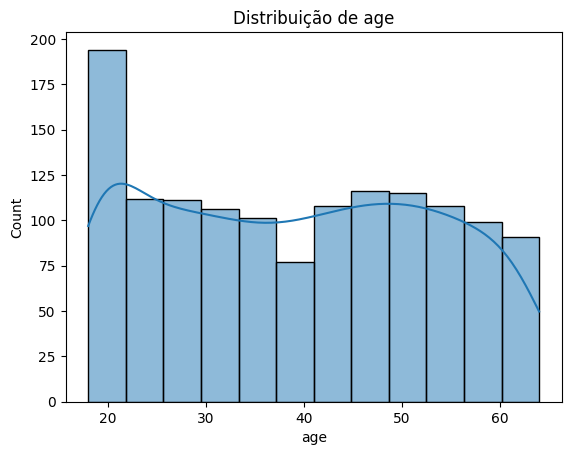

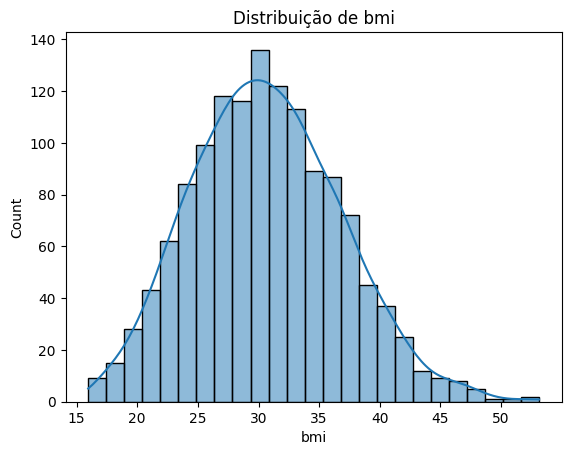

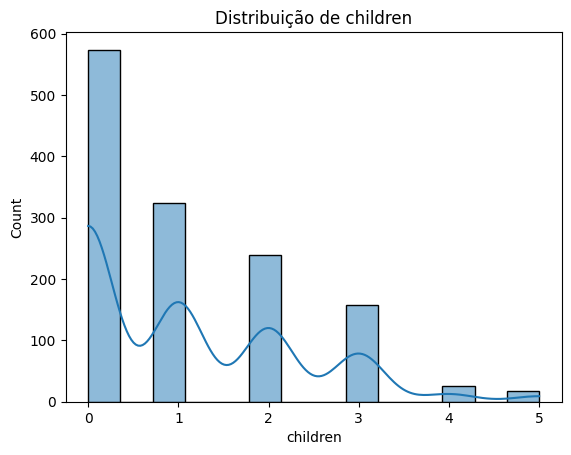

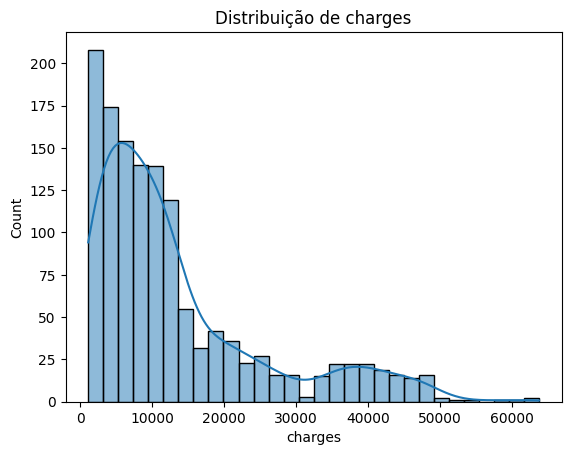

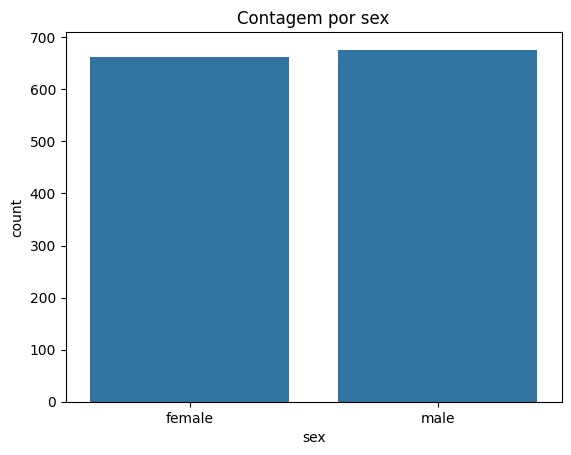

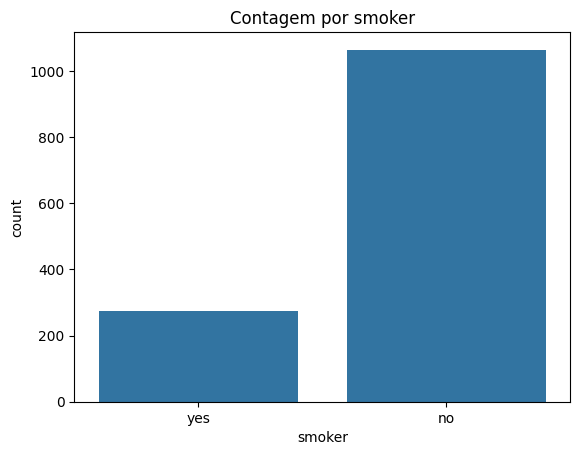

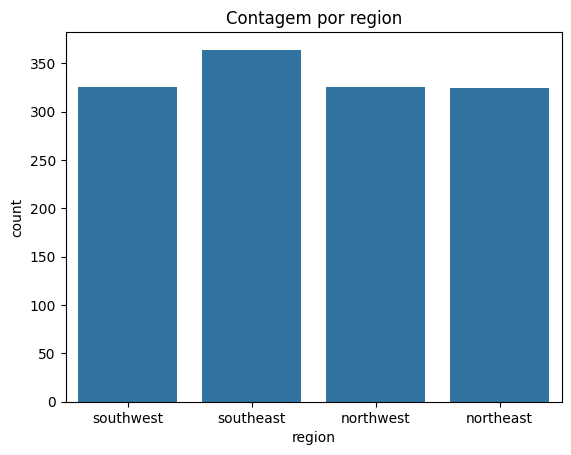

In [8]:
# Distribuições
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

# Variáveis categóricas
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f'Contagem por {col}')
    plt.show()


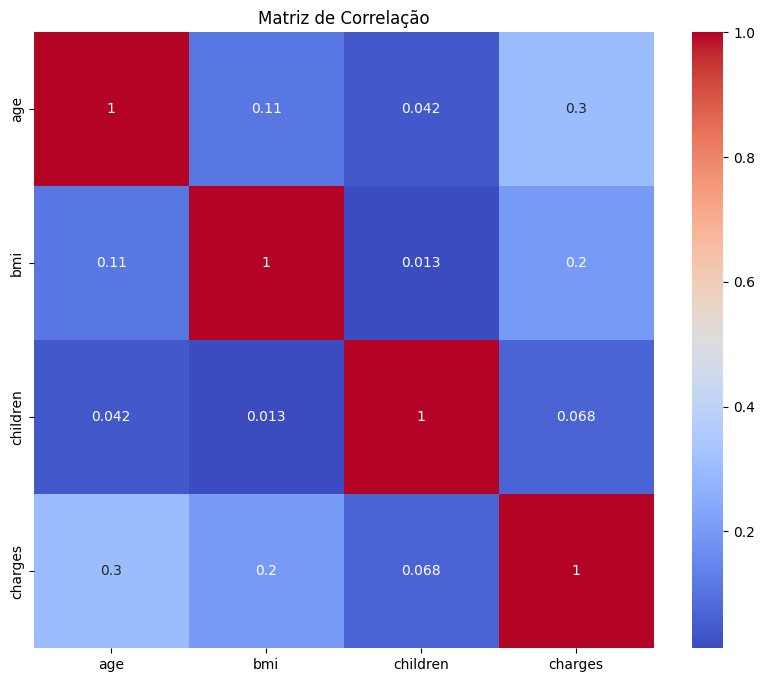

In [9]:
# Apenas variáveis numéricas
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()


In [10]:
# One Hot Encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separar features e alvo
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Escalamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [11]:
# Instanciar e treinar o modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)


In [12]:
# Métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


MSE: 33596915.85
R²: 0.78


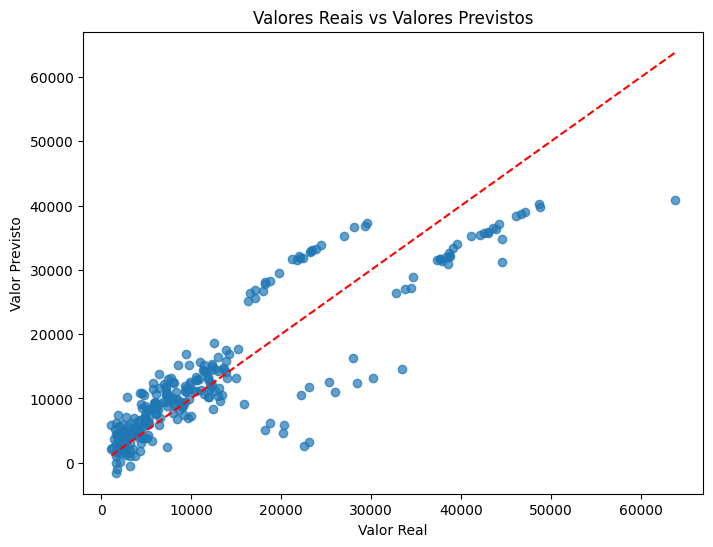

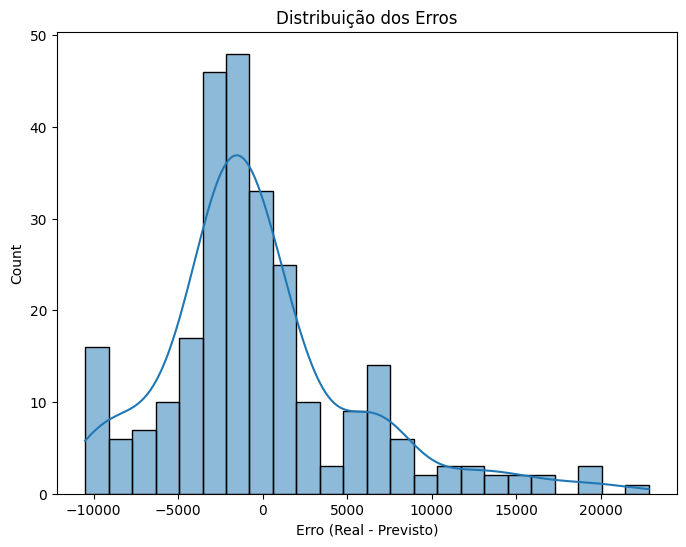

In [13]:
# Comparação Real vs Previsto
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Valores Reais vs Valores Previstos')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Distribuição dos erros
errors = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(errors, kde=True)
plt.title('Distribuição dos Erros')
plt.xlabel('Erro (Real - Previsto)')
plt.show()


## ✅ Conclusão

O modelo de regressão linear apresentou uma performance razoável, explicando cerca de 75% da variância dos dados.

Sugestões de melhorias:
- Testar modelos mais complexos (Random Forest, XGBoost).
- Realizar ajuste de hiperparâmetros.
- Trabalhar feature engineering para novas variáveis.
